<a href="https://colab.research.google.com/github/LokeshSaipureddi/HCAI-Project/blob/main/Deeplearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kagglehub -q
!pip install optuna

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft
import random
import warnings
import os
from tqdm import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.optim import Adam, AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR
from torch.optim import Adam, AdamW, SGD, RMSprop

import optuna
from optuna.trial import TrialState

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 8.6 MB/s eta 0:00:00


In [2]:
# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__}")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Set seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

PyTorch version: 2.9.0+cu126
Using device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [3]:
# ============================================================
# SECTION 2: DATA LOADING AND PREPROCESSING
# ============================================================
csv_file = "/content/drive/MyDrive/CS6140-Project/BCICIV_2a_all_patients.csv"

# Load data
df = pd.read_csv(csv_file)
df = df.dropna()
print(f"Dataset shape: {df.shape}")
print(f"Classes: {df['label'].unique()}")
print(f"\nClass distribution:\n{df['label'].value_counts()}")

# EEG columns
eeg_columns = df.columns[4:]
n_channels = len(eeg_columns)
print(f"\nNumber of channels: {n_channels}")

# Convert to numeric
df[eeg_columns] = df[eeg_columns].apply(pd.to_numeric, errors='coerce')
df = df.dropna()

# Group by epochs
grouped = df.groupby('epoch')
X, y = [], []
target_length = 201

for epoch, group in grouped:
    data = group[eeg_columns].values.T
    if data.shape[1] > target_length:
        data = data[:, :target_length]
    elif data.shape[1] < target_length:
        pad_width = target_length - data.shape[1]
        data = np.pad(data, ((0, 0), (0, pad_width)), mode='constant')
    X.append(data)
    y.append(group['label'].iloc[0])

X = np.array(X, dtype=np.float32)
y = np.array(y)
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

# Channel-wise normalization
n_samples, n_channels, n_time = X.shape
X_norm = np.zeros_like(X)

for i in range(n_samples):
    for ch in range(n_channels):
        scaler = StandardScaler()
        X_norm[i, ch] = scaler.fit_transform(X[i, ch].reshape(-1, 1)).flatten()

# Frequency features
X_freq = np.abs(np.fft.rfft(X_norm, axis=-1)).astype(np.float32)

# Sliding window
window_size = 50
stride = 10
X_windows, y_windows = [], []

for i in range(n_samples):
    time_data = X_norm[i]
    freq_data = X_freq[i]
    n_windows = (n_time - window_size) // stride + 1

    for w in range(n_windows):
        start = w * stride
        end = start + window_size
        window = time_data[:, start:end]

        freq_bins = freq_data.shape[1]
        f_start = int(start * freq_bins / n_time)
        f_end = int(end * freq_bins / n_time)
        freq_window = freq_data[:, f_start:f_end]

        if freq_window.shape[1] < window_size:
            freq_window = np.pad(freq_window, ((0,0), (0, window_size - freq_window.shape[1])))
        else:
            freq_window = freq_window[:, :window_size]

        combined = np.stack([window, freq_window], axis=0)  # (2, channels, time)
        X_windows.append(combined)
        y_windows.append(y[i])

X_windows = np.array(X_windows, dtype=np.float32)
y_windows = np.array(y_windows)
print(f"\nWindowed X shape: {X_windows.shape}")

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_windows)
num_classes = len(label_encoder.classes_)
print(f"Number of classes: {num_classes}")
print(f"Class names: {label_encoder.classes_}")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_windows, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")

Dataset shape: (492048, 26)
Classes: ['tongue' 'foot' 'right' 'left']

Class distribution:
label
left      130248
right     130248
foot      115776
tongue    115776
Name: count, dtype: int64

Number of channels: 22

X shape: (632, 22, 201)
y shape: (632,)

Windowed X shape: (10112, 2, 22, 50)
Number of classes: 4
Class names: ['foot' 'left' 'right' 'tongue']

Train: (8089, 2, 22, 50), Test: (2023, 2, 22, 50)


In [4]:
# ============================================================
# SECTION 3: DATA FORMATS AND DATALOADERS
# ============================================================

# Format 1: (batch, time, channels*2) - for sequence models (CNN-LSTM, GRU models)
X_train_seq = X_train.transpose(0, 3, 2, 1).reshape(X_train.shape[0], window_size, -1)
X_test_seq = X_test.transpose(0, 3, 2, 1).reshape(X_test.shape[0], window_size, -1)

# Format 2: (batch, 1, channels, time) - for EEGNet style (time-domain only)
X_train_eeg = X_train[:, 0:1, :, :]
X_test_eeg = X_test[:, 0:1, :, :]

print(f"Sequence format (CNN-LSTM, GRU): {X_train_seq.shape}")
print(f"EEGNet format: {X_train_eeg.shape}")

def create_dataloaders(X_train, X_test, y_train, y_test, batch_size=32):
    train_dataset = TensorDataset(
        torch.FloatTensor(X_train),
        torch.LongTensor(y_train)
    )
    test_dataset = TensorDataset(
        torch.FloatTensor(X_test),
        torch.LongTensor(y_test)
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader

Sequence format (CNN-LSTM, GRU): (8089, 50, 44)
EEGNet format: (8089, 1, 22, 50)


In [25]:
# ============================================================
# SECTION 4: MODEL DEFINITIONS
# ============================================================

# --- Model 1: CNNLSTM (Scaled ~350K params) ---
class CNNLSTM(nn.Module):
    def __init__(self, input_size, num_classes, conv1_ch=64, conv2_ch=128, conv3_ch=256,
                 lstm1_units=256, lstm2_units=128, dense_units=128, dropout=0.3):
        super().__init__()
        # Expanded CNN layers
        self.conv1 = nn.Conv1d(input_size, conv1_ch, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(conv1_ch)
        self.conv2 = nn.Conv1d(conv1_ch, conv2_ch, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(conv2_ch)
        self.conv3 = nn.Conv1d(conv2_ch, conv3_ch, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(conv3_ch)
        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(dropout)

        # Larger LSTM layers
        self.lstm1 = nn.LSTM(conv3_ch, lstm1_units, batch_first=True, num_layers=2, dropout=dropout)
        self.lstm2 = nn.LSTM(lstm1_units, lstm2_units, batch_first=True)

        # Expanded dense layers
        self.fc1 = nn.Linear(lstm2_units, dense_units)
        self.fc2 = nn.Linear(dense_units, dense_units // 2)
        self.fc3 = nn.Linear(dense_units // 2, num_classes)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = F.elu(self.bn1(self.conv1(x)))
        x = self.dropout(x)
        x = F.elu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = self.dropout(x)
        x = F.elu(self.bn3(self.conv3(x)))
        x = self.pool(x)
        x = self.dropout(x)
        x = x.transpose(1, 2)
        x, _ = self.lstm1(x)
        x, _ = self.lstm2(x)
        x = x[:, -1, :]
        x = F.elu(self.fc1(x))
        x = self.dropout(x)
        x = F.elu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x


# --- Model 2: EEGNet ---
class EEGNet(nn.Module):
    def __init__(self, n_channels, n_time, num_classes, F1=32, D=4, F2=128,
                 kernel_length=64, dropout=0.5):
        super().__init__()

        self.F1 = F1
        self.D = D
        self.F2 = F2

        # Block 1: Temporal + Spatial filtering
        self.conv1 = nn.Conv2d(1, F1, (1, kernel_length), padding=(0, kernel_length//2), bias=False)
        self.bn1 = nn.BatchNorm2d(F1)
        self.depthwise = nn.Conv2d(F1, F1 * D, (n_channels, 1), groups=F1, bias=False)
        self.bn2 = nn.BatchNorm2d(F1 * D)
        self.pool1 = nn.AvgPool2d((1, 4))
        self.dropout1 = nn.Dropout(dropout)

        # Block 2: Separable convolution (expanded)
        self.separable1 = nn.Conv2d(F1 * D, F1 * D, (1, 16), padding=(0, 8), groups=F1 * D, bias=False)
        self.separable2 = nn.Conv2d(F1 * D, F2, (1, 1), bias=False)
        self.bn3 = nn.BatchNorm2d(F2)
        self.pool2 = nn.AvgPool2d((1, 8))
        self.dropout2 = nn.Dropout(dropout)

        # Block 3: Additional separable conv block
        self.separable3 = nn.Conv2d(F2, F2, (1, 8), padding=(0, 4), groups=F2, bias=False)
        self.separable4 = nn.Conv2d(F2, F2 * 2, (1, 1), bias=False)
        self.bn4 = nn.BatchNorm2d(F2 * 2)
        self.pool3 = nn.AvgPool2d((1, 2))
        self.dropout3 = nn.Dropout(dropout)

        # Dynamically calculate flatten size
        self._to_linear = None
        self._get_flatten_size(n_channels, n_time)

        # Expanded classifier
        self.fc1 = nn.Linear(self._to_linear, 256)
        self.fc2 = nn.Linear(256, 64)
        self.fc3 = nn.Linear(64, num_classes)

    def _get_flatten_size(self, n_channels, n_time):
        """Dynamically compute the flatten size by doing a forward pass."""
        with torch.no_grad():
            x = torch.zeros(1, 1, n_channels, n_time)
            x = self._forward_features(x)
            self._to_linear = x.view(1, -1).size(1)

    def _forward_features(self, x):
        """Forward pass through feature extraction layers only."""
        # Block 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.depthwise(x)
        x = self.bn2(x)
        x = F.elu(x)
        x = self.pool1(x)
        x = self.dropout1(x)
        # Block 2
        x = self.separable1(x)
        x = self.separable2(x)
        x = self.bn3(x)
        x = F.elu(x)
        x = self.pool2(x)
        x = self.dropout2(x)
        # Block 3
        x = self.separable3(x)
        x = self.separable4(x)
        x = self.bn4(x)
        x = F.elu(x)
        x = self.pool3(x)
        x = self.dropout3(x)
        return x

    def forward(self, x):
        x = self._forward_features(x)
        # Classifier
        x = x.view(x.size(0), -1)
        x = F.elu(self.fc1(x))
        x = self.dropout3(x)
        x = F.elu(self.fc2(x))
        x = self.fc3(x)
        return x


class DeepConvNet(nn.Module):
    def __init__(self, n_channels, n_time, num_classes, dropout=0.5):
        super().__init__()

        self.n_time = n_time

        # Determine number of blocks based on input size
        # Each block with kernel=5 and pool=2 roughly halves temporal dim
        # Minimum temporal size needed per block: ~10 samples
        self.num_blocks = min(5, max(2, int(np.log2(n_time / 10))))

        # Block 1: Always present
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 50, (1, 5), padding=(0, 2)),
            nn.Conv2d(50, 50, (n_channels, 1), bias=False),
            nn.BatchNorm2d(50),
            nn.ELU(),
            nn.MaxPool2d((1, 2)),
            nn.Dropout(dropout)
        )

        # Block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(50, 100, (1, 5), padding=(0, 2)),
            nn.BatchNorm2d(100),
            nn.ELU(),
            nn.MaxPool2d((1, 2)),
            nn.Dropout(dropout)
        )

        # Block 3
        self.block3 = nn.Sequential(
            nn.Conv2d(100, 200, (1, 5), padding=(0, 2)),
            nn.BatchNorm2d(200),
            nn.ELU(),
            nn.MaxPool2d((1, 2)),
            nn.Dropout(dropout)
        ) if self.num_blocks >= 3 else None

        # Block 4
        self.block4 = nn.Sequential(
            nn.Conv2d(200, 400, (1, 5), padding=(0, 2)),
            nn.BatchNorm2d(400),
            nn.ELU(),
            nn.MaxPool2d((1, 2)),
            nn.Dropout(dropout)
        ) if self.num_blocks >= 4 else None

        # Block 5
        self.block5 = nn.Sequential(
            nn.Conv2d(400, 400, (1, 5), padding=(0, 2)),
            nn.BatchNorm2d(400),
            nn.ELU(),
            nn.MaxPool2d((1, 2)),
            nn.Dropout(dropout)
        ) if self.num_blocks >= 5 else None

        # Dynamically calculate flatten size
        self._to_linear = None
        self._get_flatten_size(n_channels, n_time)

        # Classifier
        self.fc1 = nn.Linear(self._to_linear, 256)
        self.fc2 = nn.Linear(256, 64)
        self.fc3 = nn.Linear(64, num_classes)
        self.dropout_fc = nn.Dropout(dropout)

    def _forward_features(self, x):
        x = self.block1(x)
        x = self.block2(x)
        if self.block3 is not None:
            x = self.block3(x)
        if self.block4 is not None:
            x = self.block4(x)
        if self.block5 is not None:
            x = self.block5(x)
        return x

    def _get_flatten_size(self, n_ch, n_t):
        with torch.no_grad():
            x = torch.zeros(1, 1, n_ch, n_t)
            x = self._forward_features(x)
            self._to_linear = x.view(1, -1).size(1)

    def forward(self, x):
        x = self._forward_features(x)
        x = x.view(x.size(0), -1)
        x = F.elu(self.fc1(x))
        x = self.dropout_fc(x)
        x = F.elu(self.fc2(x))
        x = self.fc3(x)
        return x


# --- Model 4: GRU Regularized ---
class GRURegularized(nn.Module):
    def __init__(self, input_size, num_classes, gru_units=128, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(input_size, gru_units, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(gru_units * window_size, num_classes)  # Flatten all timesteps

    def forward(self, x):
        # x: (batch, time, features)
        gru_out, _ = self.gru(x)  # (batch, time, gru_units)
        gru_out = self.dropout(gru_out)
        gru_out = gru_out.contiguous().view(gru_out.size(0), -1)  # Flatten
        out = self.fc(gru_out)
        return out


# --- Model 5: Fast BiGRU CNN ---
class FastBiGRUCNN(nn.Module):
    def __init__(self, input_size, num_classes, gru_units=192, conv_filters=64,
                 conv_kernel=5, dense_units=128, spatial_dropout=0.15, dropout=0.3):
        super().__init__()

        # Bidirectional GRU
        self.bigru = nn.GRU(input_size, gru_units, batch_first=True, bidirectional=True)
        self.bn1 = nn.BatchNorm1d(gru_units * 2)
        self.spatial_dropout = nn.Dropout(spatial_dropout)

        # Lightweight CNN block
        self.conv = nn.Conv1d(gru_units * 2, conv_filters, conv_kernel, padding=conv_kernel//2)
        self.bn2 = nn.BatchNorm1d(conv_filters)

        # Dense classifier
        self.fc1 = nn.Linear(conv_filters * 2, dense_units)  # *2 for avg+max pooling concat
        self.bn3 = nn.BatchNorm1d(dense_units)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(dense_units, num_classes)

    def forward(self, x):
        # x: (batch, time, features)

        # BiGRU
        gru_out, _ = self.bigru(x)  # (batch, time, gru_units*2)
        gru_out = gru_out.transpose(1, 2)  # (batch, gru_units*2, time)
        gru_out = self.bn1(gru_out)
        gru_out = self.spatial_dropout(gru_out)

        # CNN
        conv_out = F.relu(self.conv(gru_out))  # (batch, conv_filters, time)
        conv_out = self.bn2(conv_out)

        # Global pooling (avg + max concatenated)
        avg_pool = torch.mean(conv_out, dim=2)  # (batch, conv_filters)
        max_pool = torch.max(conv_out, dim=2)[0]  # (batch, conv_filters)
        pooled = torch.cat([avg_pool, max_pool], dim=1)  # (batch, conv_filters*2)

        # Dense classifier
        x = F.relu(self.fc1(pooled))
        x = self.bn3(x)
        x = self.dropout(x)
        out = self.fc2(x)
        return out

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, balanced_accuracy_score,
    top_k_accuracy_score
)
import torch
import torch.nn as nn
from torch.optim import Adam, AdamW, SGD, RMSprop


# ============================================================
# TRAINING UTILITIES
# ============================================================

def get_optimizer(model, optimizer_name, lr, weight_decay=1e-4):
    """Get optimizer by name"""
    if optimizer_name == 'adam':
        return Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == 'adamw':
        return AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == 'sgd':
        return SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    elif optimizer_name == 'rmsprop':
        return RMSprop(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")


def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += y_batch.size(0)
        correct += predicted.eq(y_batch).sum().item()

    return total_loss / len(train_loader), correct / total


def evaluate(model, test_loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += y_batch.size(0)
            correct += predicted.eq(y_batch).sum().item()

    return total_loss / len(test_loader), correct / total


# ============================================================
# METRICS EVALUATION
# ============================================================

def evaluate_metrics(model, test_loader, device, label_encoder, num_classes):
    """Compute Accuracy, Precision, Recall, F1-Score metrics."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
            all_probs.extend(probs)

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # Core metrics
    metrics = {
        'Accuracy': accuracy_score(all_labels, all_preds),
        'Balanced Accuracy': balanced_accuracy_score(all_labels, all_preds),
        'Precision (Macro)': precision_score(all_labels, all_preds, average='macro', zero_division=0),
        'Precision (Weighted)': precision_score(all_labels, all_preds, average='weighted', zero_division=0),
        'Recall (Macro)': recall_score(all_labels, all_preds, average='macro', zero_division=0),
        'Recall (Weighted)': recall_score(all_labels, all_preds, average='weighted', zero_division=0),
        'F1-Score (Macro)': f1_score(all_labels, all_preds, average='macro', zero_division=0),
        'F1-Score (Weighted)': f1_score(all_labels, all_preds, average='weighted', zero_division=0),
    }

    # Top-K Accuracy
    if num_classes > 2:
        metrics['Top-2 Accuracy'] = top_k_accuracy_score(all_labels, all_probs, k=2)
        if num_classes > 3:
            metrics['Top-3 Accuracy'] = top_k_accuracy_score(all_labels, all_probs, k=3)

    # Per-class metrics
    class_names = label_encoder.classes_
    per_class = pd.DataFrame({
        'Class': class_names,
        'Precision': precision_score(all_labels, all_preds, average=None, zero_division=0),
        'Recall': recall_score(all_labels, all_preds, average=None, zero_division=0),
        'F1-Score': f1_score(all_labels, all_preds, average=None, zero_division=0)
    })

    conf_matrix = confusion_matrix(all_labels, all_preds)
    class_report = classification_report(all_labels, all_preds, target_names=class_names, zero_division=0)

    return metrics, per_class, conf_matrix, class_report


# ============================================================
# TRAINING FUNCTION
# ============================================================

def train_model(model, train_loader, test_loader, epochs, lr,
                optimizer_name='adam', weight_decay=1e-4, device='cuda', model_name='model'):
    """Train model and return metrics."""
    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print(f"Device: {device}")
    print(f"Epochs: {epochs} | LR: {lr} | Optimizer: {optimizer_name}")
    print(f"{'='*60}")

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = get_optimizer(model, optimizer_name, lr, weight_decay)

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}\n")

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, test_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    _, test_acc = evaluate(model, test_loader, criterion, device)
    print(f"\n{model_name} Final Test Accuracy: {test_acc:.4f}")

    if device == 'cuda' or (hasattr(device, 'type') and device.type == 'cuda'):
        print(f"GPU Memory Used: {torch.cuda.memory_allocated(0)/1024**2:.1f} MB")

    return model, history, test_acc


# ============================================================
# PLOTTING FUNCTIONS
# ============================================================

def plot_history(history, model_name):
    """Plot training history."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history['train_acc'], label='Train')
    axes[0].plot(history['val_acc'], label='Val')
    axes[0].set_title(f'{model_name} - Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history['train_loss'], label='Train')
    axes[1].plot(history['val_loss'], label='Val')
    axes[1].set_title(f'{model_name} - Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f'{model_name}_history.png', dpi=150)
    plt.show()


def plot_metrics(model, test_loader, model_name, label_encoder, device, num_classes):
    """Plot confusion matrix and per-class metrics."""
    metrics, per_class, conf_mat, report = evaluate_metrics(
        model, test_loader, device, label_encoder, num_classes
    )

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    # 1. Confusion Matrix
    sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=axes[0, 0])
    axes[0, 0].set_xlabel('Predicted')
    axes[0, 0].set_ylabel('Actual')
    axes[0, 0].set_title(f'{model_name} - Confusion Matrix')

    # 2. Normalized Confusion Matrix
    conf_mat_norm = conf_mat.astype('float') / conf_mat.sum(axis=1)[:, np.newaxis]
    sns.heatmap(conf_mat_norm, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=axes[0, 1])
    axes[0, 1].set_xlabel('Predicted')
    axes[0, 1].set_ylabel('Actual')
    axes[0, 1].set_title(f'{model_name} - Normalized Confusion Matrix')

    # 3. Per-Class Metrics
    x = np.arange(len(label_encoder.classes_))
    width = 0.25
    axes[1, 0].bar(x - width, per_class['Precision'], width, label='Precision', color='steelblue')
    axes[1, 0].bar(x, per_class['Recall'], width, label='Recall', color='darkorange')
    axes[1, 0].bar(x + width, per_class['F1-Score'], width, label='F1-Score', color='forestgreen')
    axes[1, 0].set_xlabel('Class')
    axes[1, 0].set_ylabel('Score')
    axes[1, 0].set_title(f'{model_name} - Per-Class Metrics')
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(label_encoder.classes_, rotation=45, ha='right')
    axes[1, 0].legend()
    axes[1, 0].set_ylim(0, 1.1)

    # 4. Overall Metrics
    main_metrics = ['Accuracy', 'Balanced Accuracy', 'Precision (Macro)',
                    'Recall (Macro)', 'F1-Score (Macro)']
    values = [metrics[m] for m in main_metrics]
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(main_metrics)))
    bars = axes[1, 1].barh(main_metrics, values, color=colors)
    axes[1, 1].set_xlim(0, 1.1)
    axes[1, 1].set_title(f'{model_name} - Overall Metrics')
    for bar, val in zip(bars, values):
        axes[1, 1].text(val + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center')

    plt.tight_layout()
    plt.savefig(f'{model_name}_metrics.png', dpi=150)
    plt.show()

    # Print report
    print(f"\n{'='*60}")
    print(f"CLASSIFICATION REPORT - {model_name}")
    print('='*60)
    print(report)

    return metrics, per_class


# ============================================================
# RESULTS COMPARISON
# ============================================================

def plot_comparison(all_metrics):
    """Plot comprehensive comparison of all models."""
    metrics_df = pd.DataFrame(all_metrics).T.round(4)
    metrics_df = metrics_df.sort_values('F1-Score (Macro)', ascending=False)

    print("\n" + "="*80)
    print("ALL METRICS BY MODEL")
    print("="*80)
    print(metrics_df.to_string())

    metrics_df.to_csv('model_metrics_comparison.csv')
    print("\nMetrics saved to 'model_metrics_comparison.csv'")

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    models = metrics_df.index.tolist()
    x = np.arange(len(models))
    width = 0.35

    # 1. Accuracy
    for i, m in enumerate(['Accuracy', 'Balanced Accuracy']):
        axes[0, 0].bar(x + i*width, metrics_df[m], width, label=m)
    axes[0, 0].set_title('Accuracy Comparison')
    axes[0, 0].set_xticks(x + width/2)
    axes[0, 0].set_xticklabels(models, rotation=45, ha='right')
    axes[0, 0].legend()
    axes[0, 0].set_ylim(0, 1.1)

    # 2. F1-Score
    for i, m in enumerate(['F1-Score (Macro)', 'F1-Score (Weighted)']):
        axes[0, 1].bar(x + i*width, metrics_df[m], width, label=m)
    axes[0, 1].set_title('F1-Score Comparison')
    axes[0, 1].set_xticks(x + width/2)
    axes[0, 1].set_xticklabels(models, rotation=45, ha='right')
    axes[0, 1].legend()
    axes[0, 1].set_ylim(0, 1.1)

    # 3. Precision
    for i, m in enumerate(['Precision (Macro)', 'Precision (Weighted)']):
        axes[1, 0].bar(x + i*width, metrics_df[m], width, label=m)
    axes[1, 0].set_title('Precision Comparison')
    axes[1, 0].set_xticks(x + width/2)
    axes[1, 0].set_xticklabels(models, rotation=45, ha='right')
    axes[1, 0].legend()
    axes[1, 0].set_ylim(0, 1.1)

    # 4. Recall
    for i, m in enumerate(['Recall (Macro)', 'Recall (Weighted)']):
        axes[1, 1].bar(x + i*width, metrics_df[m], width, label=m)
    axes[1, 1].set_title('Recall Comparison')
    axes[1, 1].set_xticks(x + width/2)
    axes[1, 1].set_xticklabels(models, rotation=45, ha='right')
    axes[1, 1].legend()
    axes[1, 1].set_ylim(0, 1.1)

    plt.tight_layout()
    plt.savefig('model_comparison.png', dpi=150)
    plt.show()

    # Best model
    best = metrics_df['F1-Score (Macro)'].idxmax()
    print(f"\nBest Model (F1-Score Macro): {best} = {metrics_df.loc[best, 'F1-Score (Macro)']:.4f}")

    return metrics_df

In [26]:
# ============================================================
# SECTION 6: HYPERPARAMETER CONFIGURATIONS
# ============================================================

# Define hyperparameters for each model
CONFIGS = {
    'CNN_LSTM': {
        'epochs': 100,
        'lr': 0.0001,
        'optimizer': 'adam',
        'batch_size': 32,
        'dropout': 0.3,
        'conv1_ch': 32,
        'conv2_ch': 64,
        'lstm1_units': 128,
        'lstm2_units': 64,
        'dense_units': 64
    },
    'EEGNet': {
        'epochs': 200,
        'lr': 0.001,
        'optimizer': 'adam',
        'batch_size': 64,
        'F1': 8,
        'D': 2,
        'F2': 16,
        'kernel_length': 64,
        'dropout': 0.5
    },
    'DeepConvNet': {
        'epochs': 75,
        'lr': 0.0005,
        'optimizer': 'adam',
        'batch_size': 32,
        'dropout': 0.5
    },
    'GRU_Regularized': {
        'epochs': 100,
        'lr': 0.0005,
        'optimizer': 'adam',
        'batch_size': 32,
        'gru_units': 128,
        'dropout': 0.2
    },
    'Fast_BiGRU_CNN': {
        'epochs': 100,
        'lr': 0.0005,
        'optimizer': 'adam',
        'batch_size': 32,
        'gru_units': 192,
        'conv_filters': 64,
        'conv_kernel': 5,
        'dense_units': 128,
        'spatial_dropout': 0.15,
        'dropout': 0.3
    }
}


Training: CNN_LSTM
Device: cuda
Epochs: 100 | LR: 0.0001 | Optimizer: adam
Total parameters: 446,340
Trainable parameters: 446,340

Epoch   1/100 | Train Loss: 1.3885 | Train Acc: 0.2412 | Val Loss: 1.3858 | Val Acc: 0.2739
Epoch  10/100 | Train Loss: 1.3461 | Train Acc: 0.3438 | Val Loss: 1.3556 | Val Acc: 0.3347
Epoch  20/100 | Train Loss: 1.2915 | Train Acc: 0.3993 | Val Loss: 1.3281 | Val Acc: 0.3821
Epoch  30/100 | Train Loss: 1.2150 | Train Acc: 0.4551 | Val Loss: 1.3433 | Val Acc: 0.3969
Epoch  40/100 | Train Loss: 1.1233 | Train Acc: 0.5212 | Val Loss: 1.2445 | Val Acc: 0.4518
Epoch  50/100 | Train Loss: 1.0044 | Train Acc: 0.5862 | Val Loss: 1.2624 | Val Acc: 0.4755
Epoch  60/100 | Train Loss: 0.8912 | Train Acc: 0.6393 | Val Loss: 1.2424 | Val Acc: 0.5146
Epoch  70/100 | Train Loss: 0.7998 | Train Acc: 0.6823 | Val Loss: 1.1211 | Val Acc: 0.5551
Epoch  80/100 | Train Loss: 0.7142 | Train Acc: 0.7199 | Val Loss: 1.0129 | Val Acc: 0.6045
Epoch  90/100 | Train Loss: 0.6423 | Tr

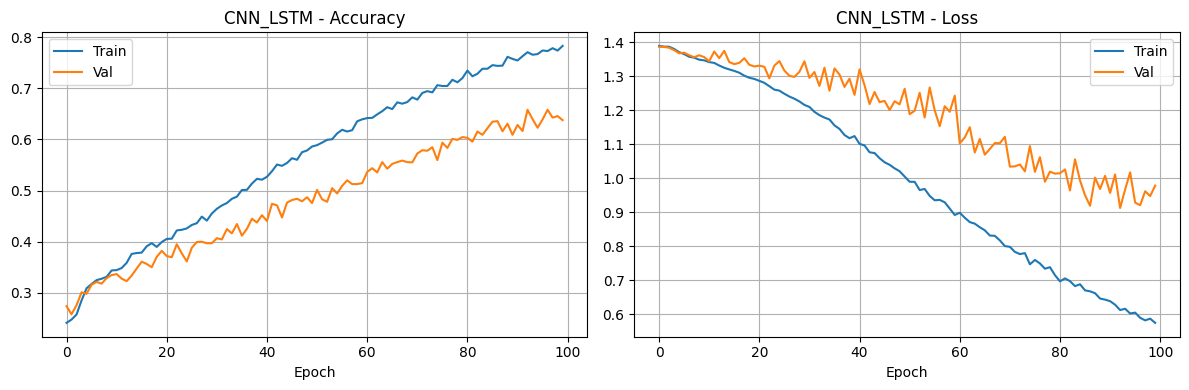

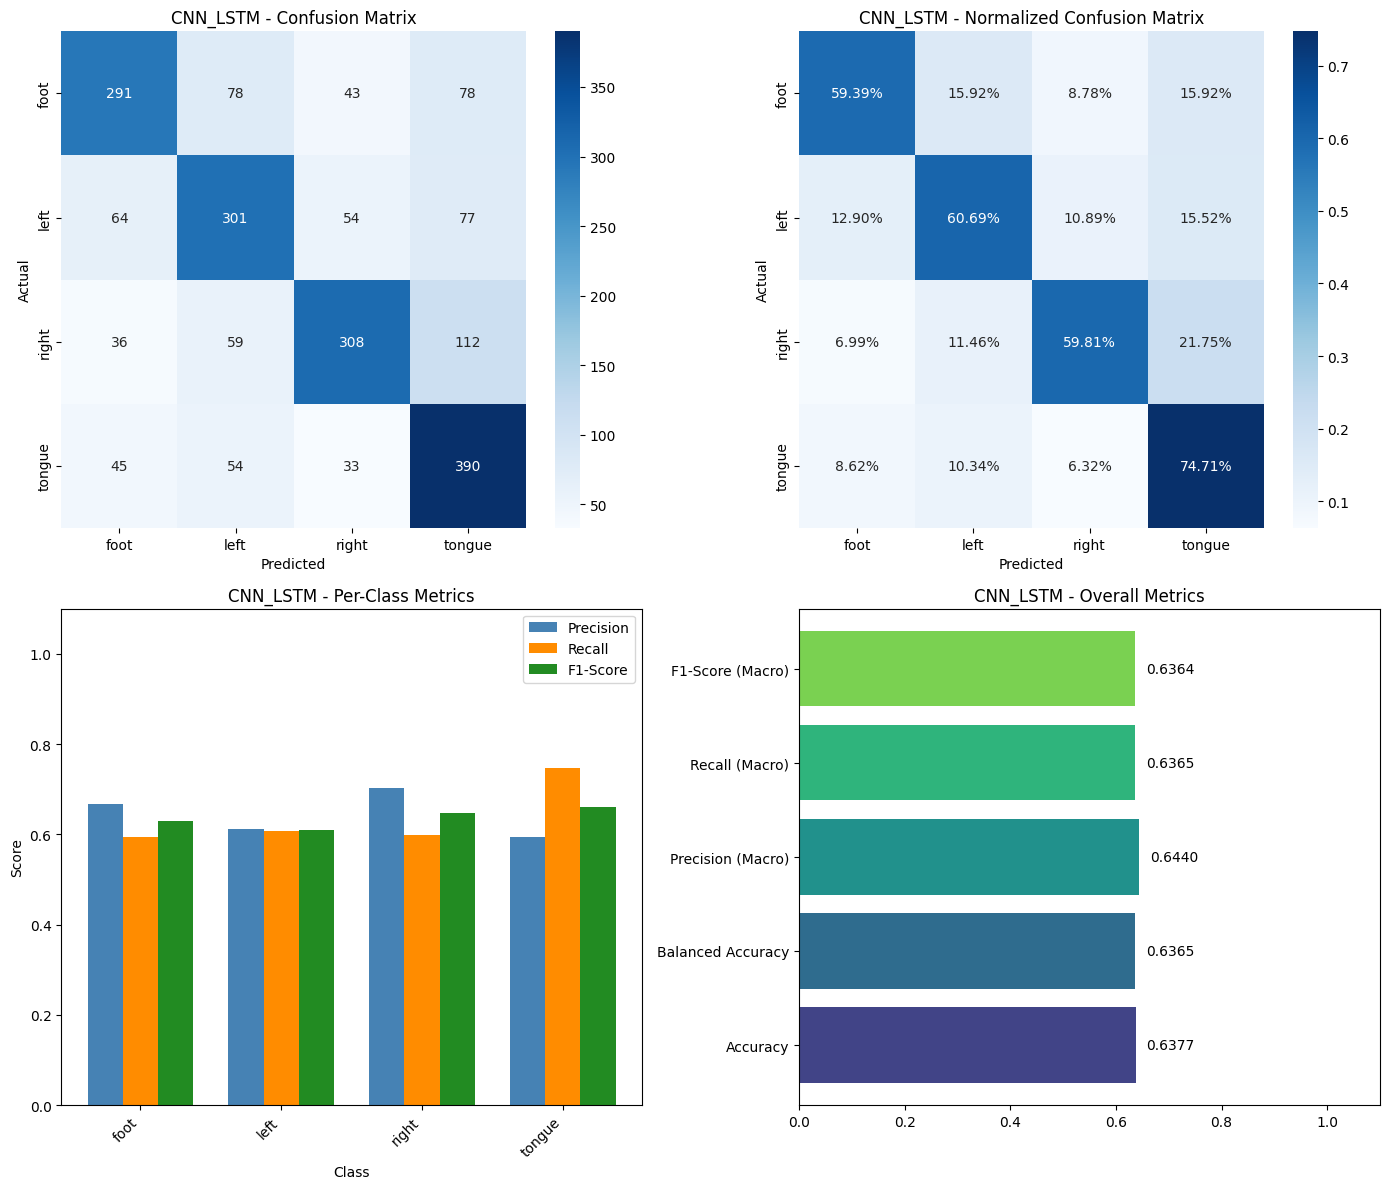


CLASSIFICATION REPORT - CNN_LSTM
              precision    recall  f1-score   support

        foot       0.67      0.59      0.63       490
        left       0.61      0.61      0.61       496
       right       0.70      0.60      0.65       515
      tongue       0.59      0.75      0.66       522

    accuracy                           0.64      2023
   macro avg       0.64      0.64      0.64      2023
weighted avg       0.64      0.64      0.64      2023



In [27]:
# ============================================================
# SECTION 7: TRAIN ALL MODELS
# ============================================================

results = {}
all_metrics = {}

# --- 1. CNN-LSTM ---
cfg = CONFIGS['CNN_LSTM']
train_loader, test_loader = create_dataloaders(X_train_seq, X_test_seq, y_train, y_test, cfg['batch_size'])
model = CNNLSTM(
    input_size=X_train_seq.shape[2], num_classes=num_classes,
    conv1_ch=cfg['conv1_ch'], conv2_ch=cfg['conv2_ch'],
    lstm1_units=cfg['lstm1_units'], lstm2_units=cfg['lstm2_units'],
    dense_units=cfg['dense_units'], dropout=cfg['dropout']
)
model, hist, acc = train_model(model, train_loader, test_loader, epochs=cfg['epochs'],
                                lr=cfg['lr'], optimizer_name=cfg['optimizer'], device=device, model_name='CNN_LSTM')
plot_history(hist, 'CNN_LSTM')
metrics, _ = plot_metrics(model, test_loader, 'CNN_LSTM', label_encoder, device, num_classes)
results['CNN_LSTM'] = acc
all_metrics['CNN_LSTM'] = metrics
torch.save(model.state_dict(), 'cnn_lstm_model.pt')


Training: EEGNet
Device: cuda
Epochs: 200 | LR: 0.001 | Optimizer: adam
Total parameters: 27,316
Trainable parameters: 27,316

Epoch   1/200 | Train Loss: 1.3996 | Train Acc: 0.2535 | Val Loss: 1.3889 | Val Acc: 0.2541
Epoch  10/200 | Train Loss: 1.3846 | Train Acc: 0.2691 | Val Loss: 1.3846 | Val Acc: 0.2719
Epoch  20/200 | Train Loss: 1.3818 | Train Acc: 0.2795 | Val Loss: 1.3796 | Val Acc: 0.2971
Epoch  30/200 | Train Loss: 1.3744 | Train Acc: 0.2972 | Val Loss: 1.3777 | Val Acc: 0.2991
Epoch  40/200 | Train Loss: 1.3673 | Train Acc: 0.3121 | Val Loss: 1.3696 | Val Acc: 0.2956
Epoch  50/200 | Train Loss: 1.3594 | Train Acc: 0.3218 | Val Loss: 1.3630 | Val Acc: 0.3114
Epoch  60/200 | Train Loss: 1.3591 | Train Acc: 0.3209 | Val Loss: 1.3611 | Val Acc: 0.3164
Epoch  70/200 | Train Loss: 1.3498 | Train Acc: 0.3321 | Val Loss: 1.3567 | Val Acc: 0.3218
Epoch  80/200 | Train Loss: 1.3436 | Train Acc: 0.3404 | Val Loss: 1.3515 | Val Acc: 0.3361
Epoch  90/200 | Train Loss: 1.3418 | Train A

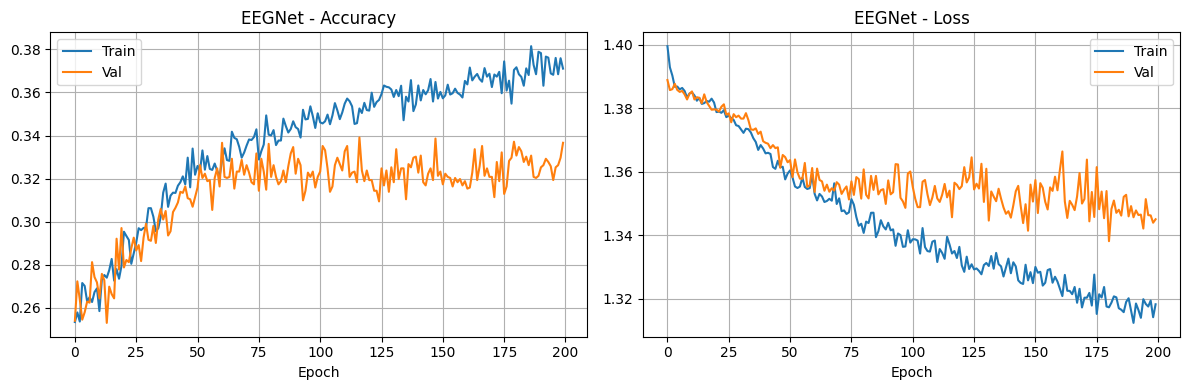

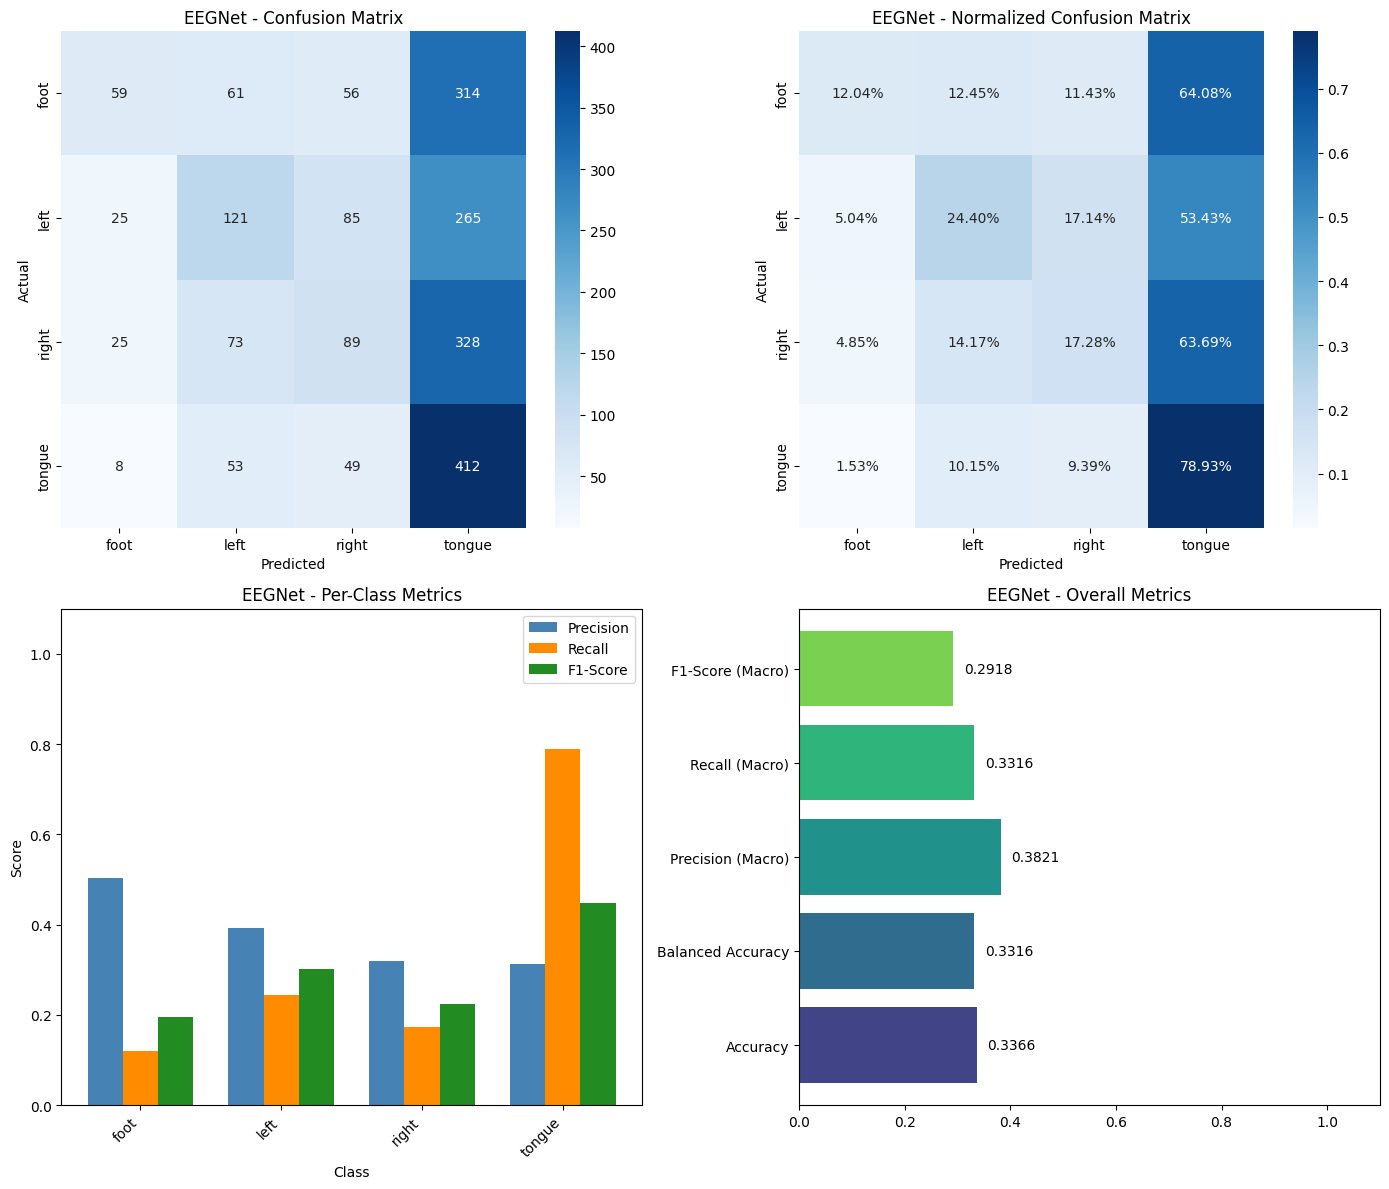


CLASSIFICATION REPORT - EEGNet
              precision    recall  f1-score   support

        foot       0.50      0.12      0.19       490
        left       0.39      0.24      0.30       496
       right       0.32      0.17      0.22       515
      tongue       0.31      0.79      0.45       522

    accuracy                           0.34      2023
   macro avg       0.38      0.33      0.29      2023
weighted avg       0.38      0.34      0.29      2023



In [20]:
# --- 2. EEGNet ---
cfg = CONFIGS['EEGNet']
train_loader, test_loader = create_dataloaders(X_train_eeg, X_test_eeg, y_train, y_test, cfg['batch_size'])
model = EEGNet(
    n_channels=n_channels, n_time=window_size, num_classes=num_classes,
    F1=cfg['F1'], D=cfg['D'], F2=cfg['F2'],
    kernel_length=cfg['kernel_length'], dropout=cfg['dropout']
)
model, hist, acc = train_model(model, train_loader, test_loader, epochs=cfg['epochs'],
                                lr=cfg['lr'], optimizer_name=cfg['optimizer'], device=device, model_name='EEGNet')
plot_history(hist, 'EEGNet')
metrics, _ = plot_metrics(model, test_loader, 'EEGNet', label_encoder, device, num_classes)
results['EEGNet'] = acc
all_metrics['EEGNet'] = metrics
torch.save(model.state_dict(), 'eegnet_model.pt')


Training: DeepConvNet
Device: cuda
Epochs: 75 | LR: 0.0005 | Optimizer: adam
Total parameters: 404,864
Trainable parameters: 404,864

Epoch   1/75 | Train Loss: 1.4113 | Train Acc: 0.2491 | Val Loss: 1.3889 | Val Acc: 0.2432
Epoch  10/75 | Train Loss: 1.3375 | Train Acc: 0.3506 | Val Loss: 1.3507 | Val Acc: 0.3406
Epoch  20/75 | Train Loss: 1.2336 | Train Acc: 0.4348 | Val Loss: 1.2996 | Val Acc: 0.3935
Epoch  30/75 | Train Loss: 1.1164 | Train Acc: 0.5138 | Val Loss: 1.2402 | Val Acc: 0.4538
Epoch  40/75 | Train Loss: 1.0285 | Train Acc: 0.5656 | Val Loss: 1.1863 | Val Acc: 0.4869
Epoch  50/75 | Train Loss: 0.9546 | Train Acc: 0.6006 | Val Loss: 1.1258 | Val Acc: 0.5284
Epoch  60/75 | Train Loss: 0.8862 | Train Acc: 0.6348 | Val Loss: 1.1381 | Val Acc: 0.5329
Epoch  70/75 | Train Loss: 0.8509 | Train Acc: 0.6543 | Val Loss: 1.0892 | Val Acc: 0.5526

DeepConvNet Final Test Accuracy: 0.5645
GPU Memory Used: 40.4 MB


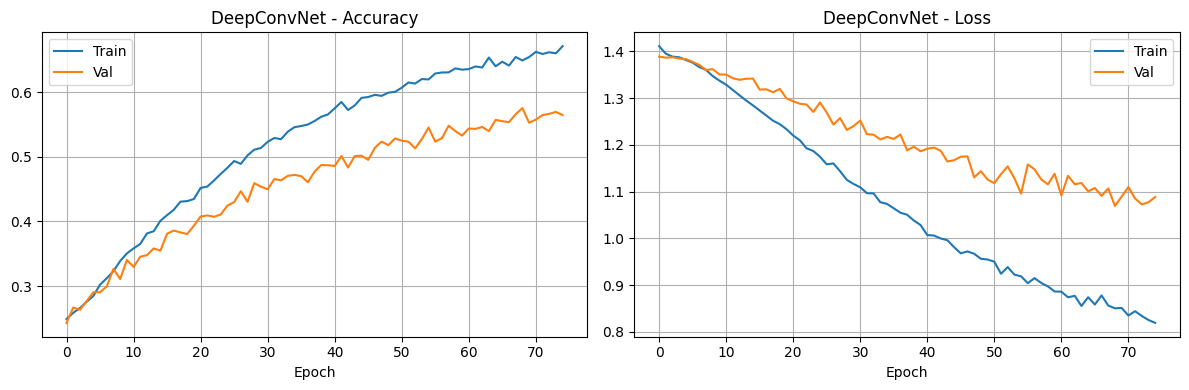

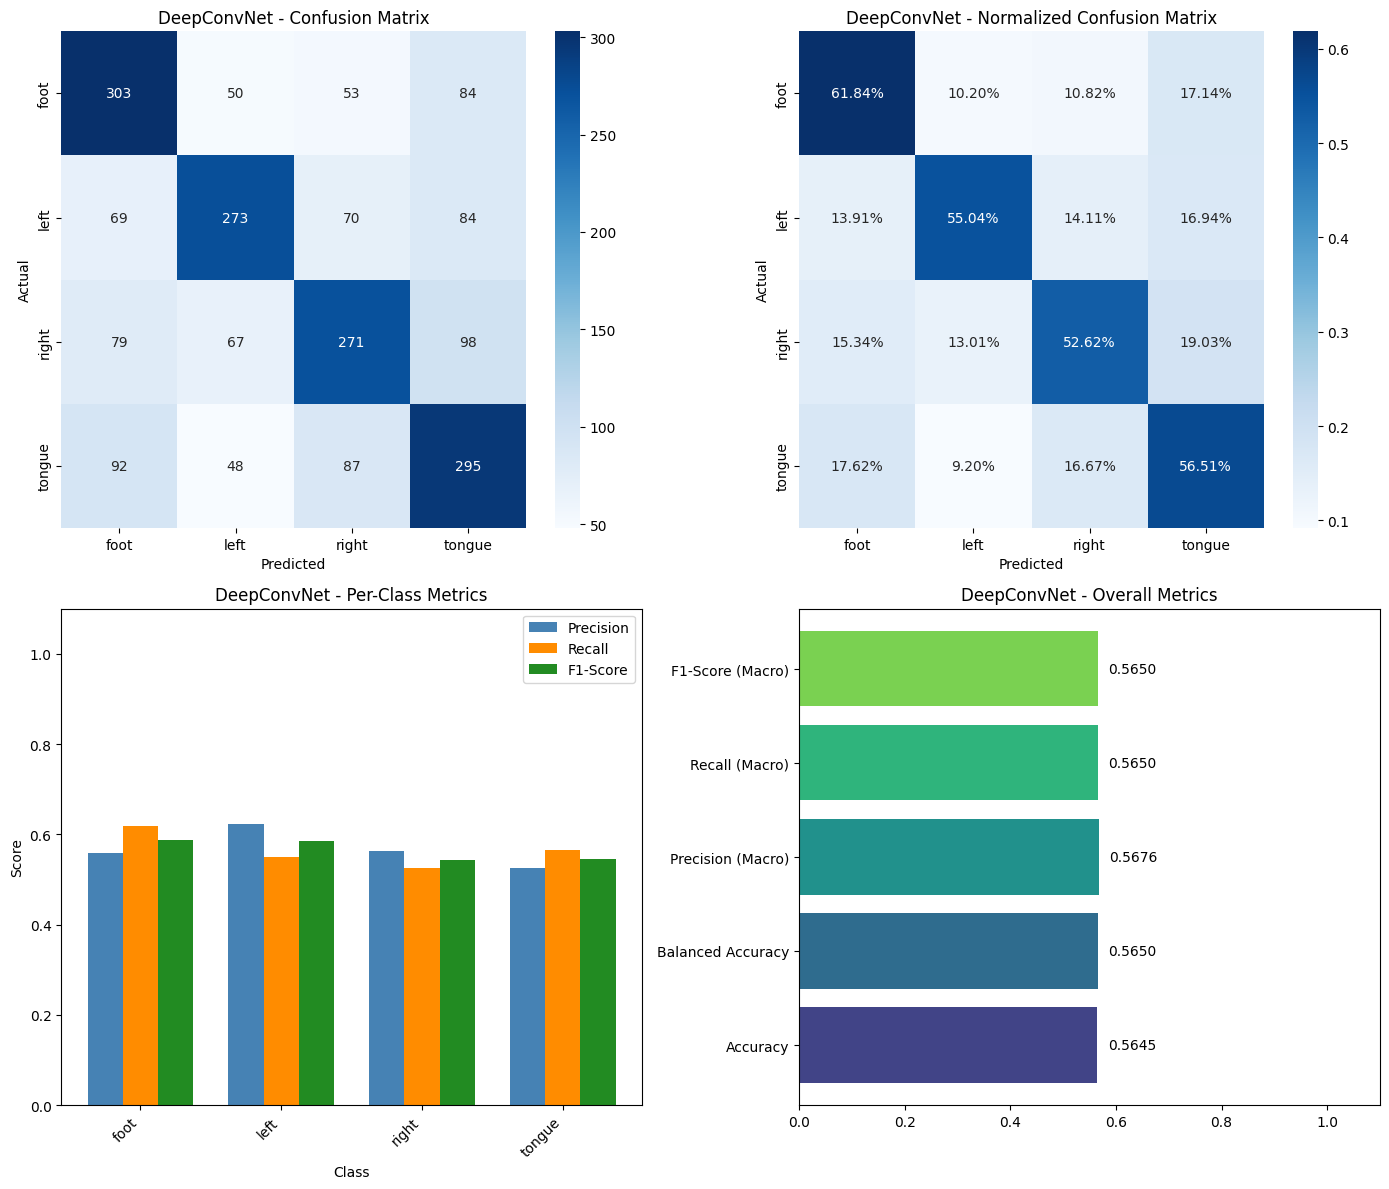


CLASSIFICATION REPORT - DeepConvNet
              precision    recall  f1-score   support

        foot       0.56      0.62      0.59       490
        left       0.62      0.55      0.58       496
       right       0.56      0.53      0.54       515
      tongue       0.53      0.57      0.54       522

    accuracy                           0.56      2023
   macro avg       0.57      0.57      0.57      2023
weighted avg       0.57      0.56      0.56      2023



In [23]:
# --- 3. DeepConvNet ---
cfg = CONFIGS['DeepConvNet']
train_loader, test_loader = create_dataloaders(X_train_eeg, X_test_eeg, y_train, y_test, cfg['batch_size'])
model = DeepConvNet(
    n_channels=n_channels, n_time=window_size, num_classes=num_classes,
    dropout=cfg['dropout']
)
model, hist, acc = train_model(model, train_loader, test_loader, epochs=cfg['epochs'],
                                lr=cfg['lr'], optimizer_name=cfg['optimizer'], device=device, model_name='DeepConvNet')
plot_history(hist, 'DeepConvNet')
metrics, _ = plot_metrics(model, test_loader, 'DeepConvNet', label_encoder, device, num_classes)
results['DeepConvNet'] = acc
all_metrics['DeepConvNet'] = metrics
torch.save(model.state_dict(), 'deepconvnet_model.pt')


Training: GRU_Regularized
Device: cuda
Epochs: 100 | LR: 0.0005 | Optimizer: adam
Total parameters: 92,420
Trainable parameters: 92,420

Epoch   1/100 | Train Loss: 1.4159 | Train Acc: 0.2817 | Val Loss: 1.3687 | Val Acc: 0.3065
Epoch  10/100 | Train Loss: 0.6383 | Train Acc: 0.7576 | Val Loss: 1.1493 | Val Acc: 0.5645
Epoch  20/100 | Train Loss: 0.0881 | Train Acc: 0.9711 | Val Loss: 1.0061 | Val Acc: 0.6990
Epoch  30/100 | Train Loss: 0.0540 | Train Acc: 0.9824 | Val Loss: 1.3035 | Val Acc: 0.6906
Epoch  40/100 | Train Loss: 0.0254 | Train Acc: 0.9913 | Val Loss: 1.4655 | Val Acc: 0.7247
Epoch  50/100 | Train Loss: 0.0521 | Train Acc: 0.9807 | Val Loss: 1.3755 | Val Acc: 0.7237
Epoch  60/100 | Train Loss: 0.0133 | Train Acc: 0.9949 | Val Loss: 1.3431 | Val Acc: 0.7519
Epoch  70/100 | Train Loss: 0.0662 | Train Acc: 0.9774 | Val Loss: 1.4734 | Val Acc: 0.7454
Epoch  80/100 | Train Loss: 0.0003 | Train Acc: 1.0000 | Val Loss: 0.9225 | Val Acc: 0.8196
Epoch  90/100 | Train Loss: 0.0017

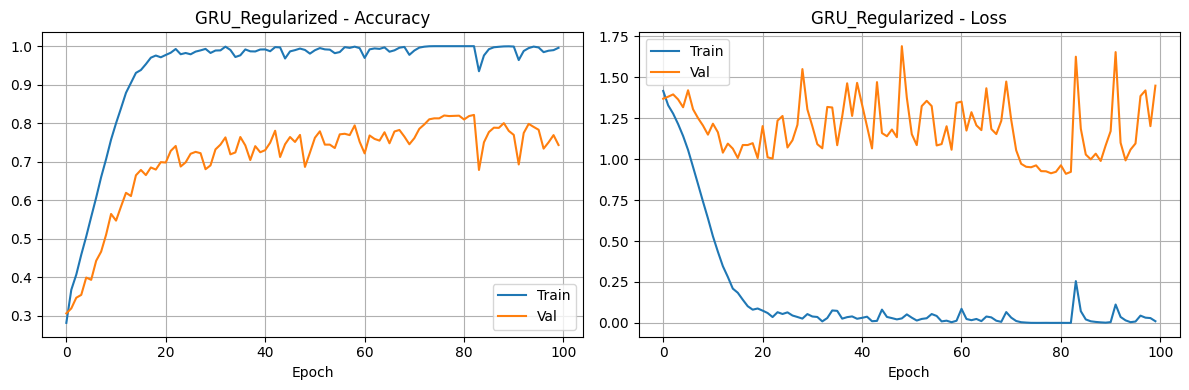

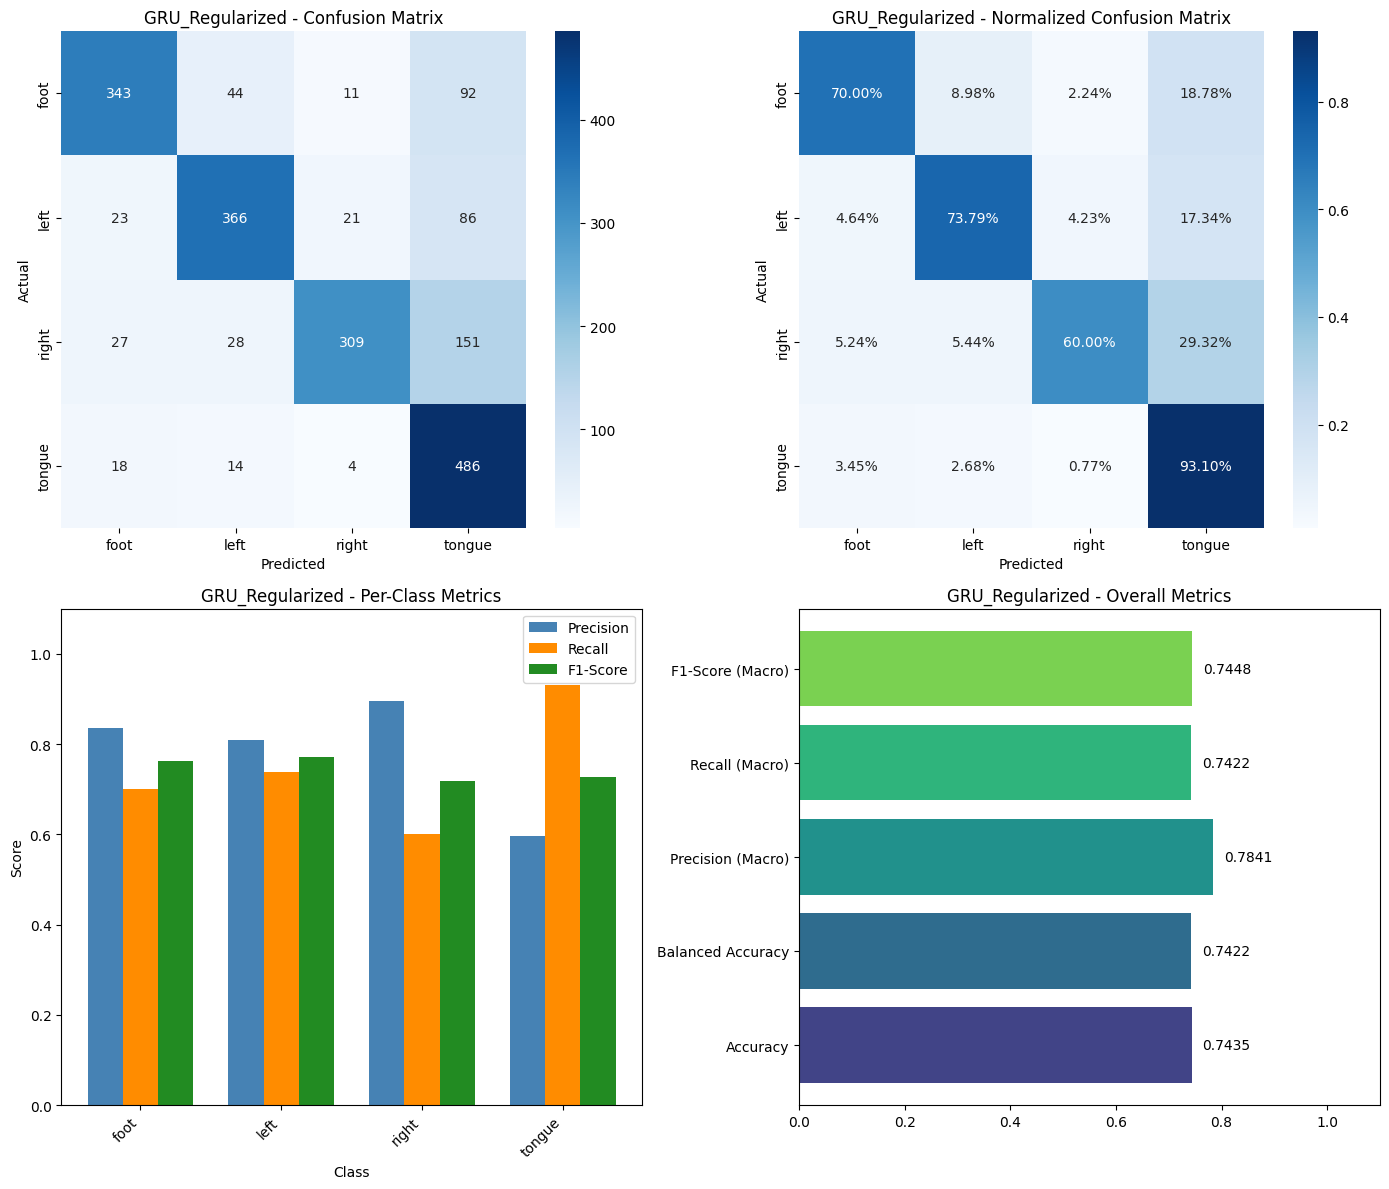


CLASSIFICATION REPORT - GRU_Regularized
              precision    recall  f1-score   support

        foot       0.83      0.70      0.76       490
        left       0.81      0.74      0.77       496
       right       0.90      0.60      0.72       515
      tongue       0.60      0.93      0.73       522

    accuracy                           0.74      2023
   macro avg       0.78      0.74      0.74      2023
weighted avg       0.78      0.74      0.74      2023



In [30]:
# --- 4. GRU Regularized ---
cfg = CONFIGS['GRU_Regularized']
train_loader, test_loader = create_dataloaders(X_train_seq, X_test_seq, y_train, y_test, cfg['batch_size'])
model = GRURegularized(
    input_size=X_train_seq.shape[2], num_classes=num_classes,
    gru_units=cfg['gru_units'], dropout=cfg['dropout']
)
model, hist, acc = train_model(model, train_loader, test_loader, epochs=cfg['epochs'],
                                lr=cfg['lr'], optimizer_name=cfg['optimizer'], device=device, model_name='GRU_Regularized')
plot_history(hist, 'GRU_Regularized')
metrics, _ = plot_metrics(model, test_loader, 'GRU_Regularized', label_encoder, device, num_classes)
results['GRU_Regularized'] = acc
all_metrics['GRU_Regularized'] = metrics
torch.save(model.state_dict(), 'gru_regularized_model.pt')


Training: Fast_BiGRU_CNN
Device: cuda
Epochs: 100 | LR: 0.0005 | Optimizer: adam
Total parameters: 415,300
Trainable parameters: 415,300

Epoch   1/100 | Train Loss: 1.4074 | Train Acc: 0.2954 | Val Loss: 1.3597 | Val Acc: 0.3332
Epoch  10/100 | Train Loss: 0.5315 | Train Acc: 0.7960 | Val Loss: 0.8579 | Val Acc: 0.6812
Epoch  20/100 | Train Loss: 0.1178 | Train Acc: 0.9568 | Val Loss: 0.5572 | Val Acc: 0.8171
Epoch  30/100 | Train Loss: 0.0587 | Train Acc: 0.9805 | Val Loss: 0.5087 | Val Acc: 0.8468
Epoch  40/100 | Train Loss: 0.0695 | Train Acc: 0.9767 | Val Loss: 0.4360 | Val Acc: 0.8695
Epoch  50/100 | Train Loss: 0.0524 | Train Acc: 0.9823 | Val Loss: 0.3834 | Val Acc: 0.8868
Epoch  60/100 | Train Loss: 0.0292 | Train Acc: 0.9906 | Val Loss: 0.3572 | Val Acc: 0.8957
Epoch  70/100 | Train Loss: 0.0528 | Train Acc: 0.9816 | Val Loss: 0.4467 | Val Acc: 0.8838
Epoch  80/100 | Train Loss: 0.0415 | Train Acc: 0.9864 | Val Loss: 0.3328 | Val Acc: 0.9016
Epoch  90/100 | Train Loss: 0.025

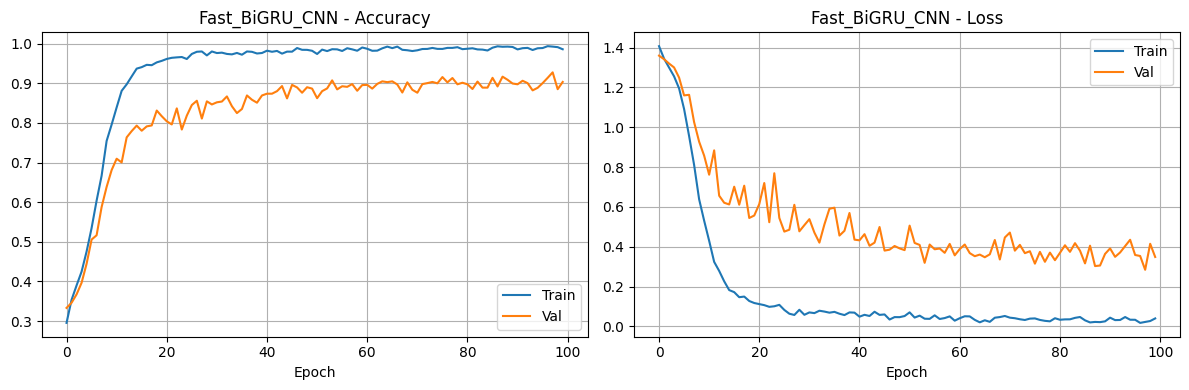

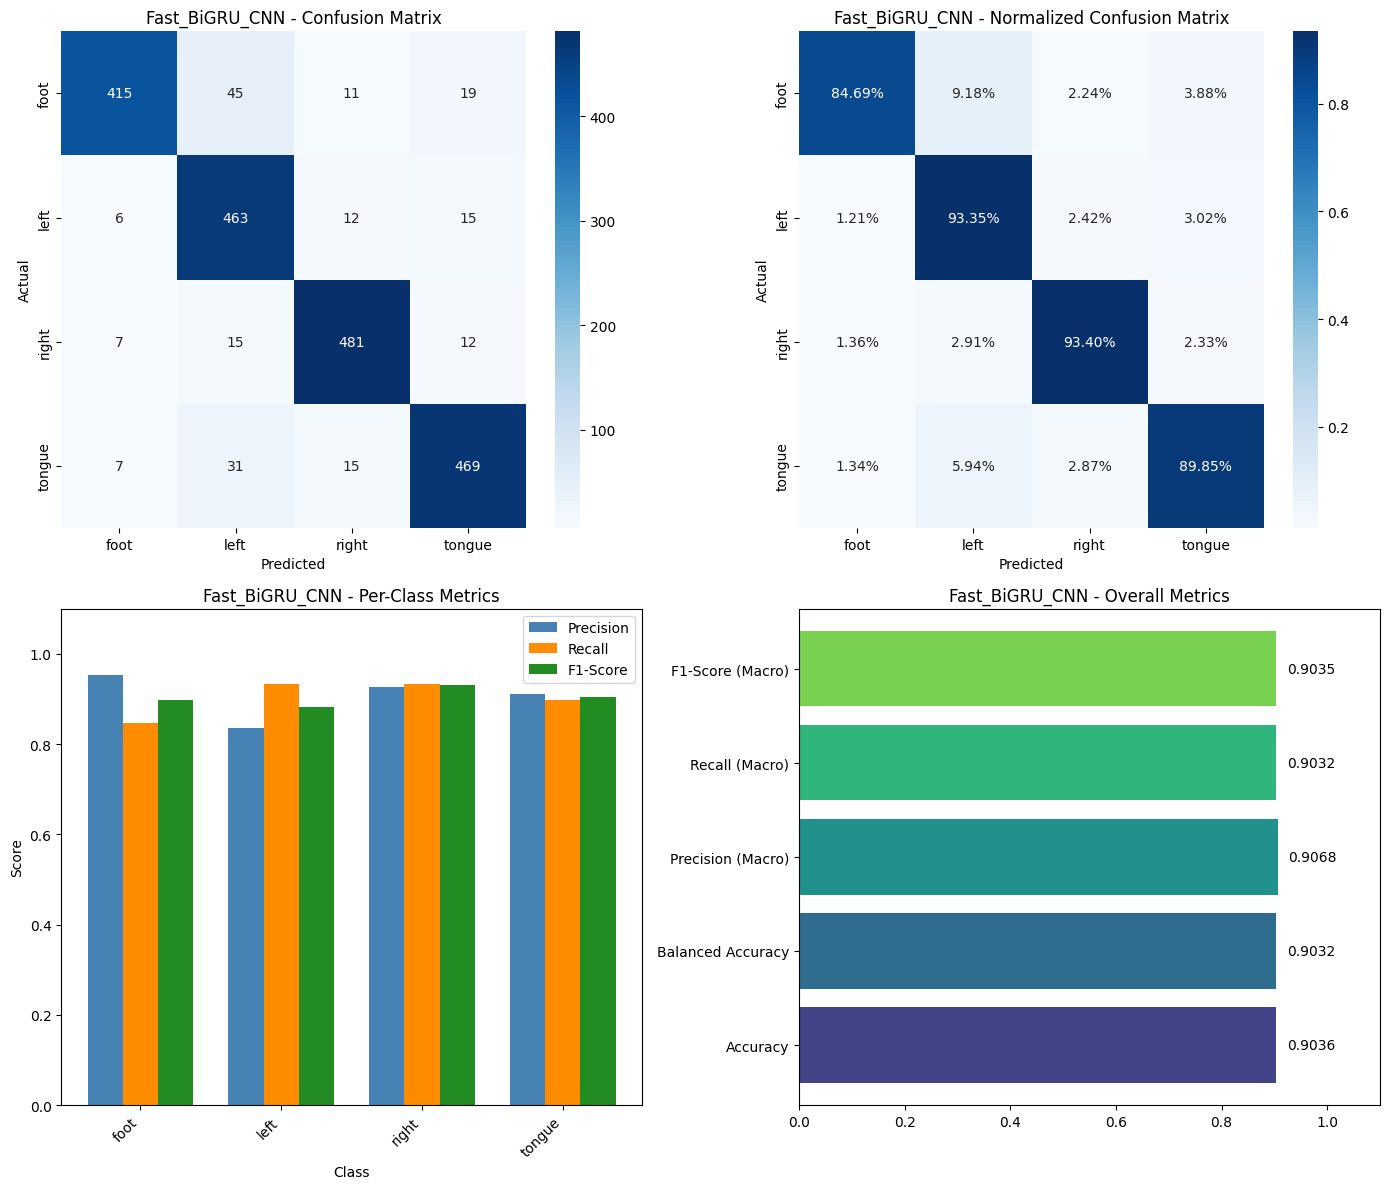


CLASSIFICATION REPORT - Fast_BiGRU_CNN
              precision    recall  f1-score   support

        foot       0.95      0.85      0.90       490
        left       0.84      0.93      0.88       496
       right       0.93      0.93      0.93       515
      tongue       0.91      0.90      0.90       522

    accuracy                           0.90      2023
   macro avg       0.91      0.90      0.90      2023
weighted avg       0.91      0.90      0.90      2023



In [31]:
# --- 5. Fast BiGRU CNN ---
cfg = CONFIGS['Fast_BiGRU_CNN']
train_loader, test_loader = create_dataloaders(X_train_seq, X_test_seq, y_train, y_test, cfg['batch_size'])
model = FastBiGRUCNN(
    input_size=X_train_seq.shape[2], num_classes=num_classes,
    gru_units=cfg['gru_units'], conv_filters=cfg['conv_filters'],
    conv_kernel=cfg['conv_kernel'], dense_units=cfg['dense_units'],
    spatial_dropout=cfg['spatial_dropout'], dropout=cfg['dropout']
)
model, hist, acc = train_model(model, train_loader, test_loader, epochs=cfg['epochs'],
                                lr=cfg['lr'], optimizer_name=cfg['optimizer'], device=device, model_name='Fast_BiGRU_CNN')
plot_history(hist, 'Fast_BiGRU_CNN')
metrics, _ = plot_metrics(model, test_loader, 'Fast_BiGRU_CNN', label_encoder, device, num_classes)
results['Fast_BiGRU_CNN'] = acc
all_metrics['Fast_BiGRU_CNN'] = metrics
torch.save(model.state_dict(), 'fast_bigru_cnn_model.pt')

In [ ]:
class TunableFastBiGRUCNN(nn.Module):
    def __init__(self, input_size, num_classes, gru_units, conv_filters,
                 conv_kernel, dense_units, spatial_dropout, dropout):
        super().__init__()

        # Bidirectional GRU
        self.bigru = nn.GRU(input_size, gru_units, batch_first=True, bidirectional=True)
        self.bn1 = nn.BatchNorm1d(gru_units * 2)
        self.spatial_dropout = nn.Dropout(spatial_dropout)

        # Lightweight CNN block
        self.conv = nn.Conv1d(gru_units * 2, conv_filters, conv_kernel, padding=conv_kernel//2)
        self.bn2 = nn.BatchNorm1d(conv_filters)

        # Dense classifier
        self.fc1 = nn.Linear(conv_filters * 2, dense_units)  # *2 for avg+max pooling
        self.bn3 = nn.BatchNorm1d(dense_units)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(dense_units, num_classes)

    def forward(self, x):
        # x: (batch, time, features)

        # BiGRU
        gru_out, _ = self.bigru(x)  # (batch, time, gru_units*2)
        gru_out = gru_out.transpose(1, 2)  # (batch, gru_units*2, time)
        gru_out = self.bn1(gru_out)
        gru_out = self.spatial_dropout(gru_out)

        # CNN
        conv_out = F.relu(self.conv(gru_out))  # (batch, conv_filters, time)
        conv_out = self.bn2(conv_out)

        # Global pooling (avg + max concatenated)
        avg_pool = torch.mean(conv_out, dim=2)  # (batch, conv_filters)
        max_pool = torch.max(conv_out, dim=2)[0]  # (batch, conv_filters)
        pooled = torch.cat([avg_pool, max_pool], dim=1)  # (batch, conv_filters*2)

        # Dense classifier
        x = F.relu(self.fc1(pooled))
        x = self.bn3(x)
        x = self.dropout(x)
        out = self.fc2(x)
        return out

In [ ]:
def objective(trial, X_train_seq, X_test_seq, y_train, y_test, num_classes, device, configs):
    """Objective function for Fast BiGRU CNN"""

    # Hyperparameters for training
    lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    optimizer_name = trial.suggest_categorical('optimizer', ['adam', 'adamw', 'sgd', 'rmsprop'])
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    epochs = trial.suggest_int('epochs', 50, 150) # Suggest epochs
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True) # Suggest weight_decay

    # Load fixed hyperparameters for TunableFastBiGRUCNN from CONFIGS
    model_cfg = configs['Fast_BiGRU_CNN']

    # Create dataloaders for sequence models
    train_loader, test_loader = create_dataloaders(X_train_seq, X_test_seq, y_train, y_test, batch_size)

    # Instantiate the model with suggested hyperparameters
    model = TunableFastBiGRUCNN(
        input_size=X_train_seq.shape[2], num_classes=num_classes,
        gru_units=model_cfg['gru_units'], conv_filters=model_cfg['conv_filters'],
        conv_kernel=model_cfg['conv_kernel'], dense_units=model_cfg['dense_units'],
        spatial_dropout=model_cfg['spatial_dropout'], dropout=model_cfg['dropout']
    )

    # Train and evaluate the model
    _, _, accuracy = train_model(
        model, train_loader, test_loader, epochs, lr, optimizer_name, weight_decay, device, model_name='TunableFastBiGRUCNN'
    )
    return accuracy

In [ ]:
# ============================================================
# SECTION 6: RUN HYPERPARAMETER SEARCH
# ============================================================

N_TRIALS = 30

print(f"\n{'='*60}")
print(f"Starting Optuna Hyperparameter Search: Fast_BiGRU_CNN")
print(f"Number of trials: {N_TRIALS}")
print(f"Device: {device}")
print(f"{'='*60}\n")

study = optuna.create_study(direction='maximize')
study.optimize(lambda trial: objective(trial, X_train_seq, X_test_seq, y_train, y_test, num_classes, device, CONFIGS), n_trials=N_TRIALS, show_progress_bar=True)

# ============================================================
# SECTION 7: RESULTS
# ============================================================

print("\n" + "="*60)
print("OPTIMIZATION RESULTS")
print("="*60)

print(f"\nBest Trial: #{study.best_trial.number}")
print(f"Best Accuracy: {study.best_trial.value:.4f}")
print("\nBest Hyperparameters:")
for key, value in study.best_trial.params.items():
    print(f"  {key}: {value}")

# Visualization
fig = optuna.visualization.plot_optimization_history(study)
fig.show()

try:
    fig = optuna.visualization.plot_param_importances(study)
    fig.show()
except:
    print("Could not generate parameter importance plot")

[I 2025-12-13 04:07:30,741] A new study created in memory with name: no-name-1731f8f1-0251-406d-b331-2b74af320465



Starting Optuna Hyperparameter Search: Fast_BiGRU_CNN
Number of trials: 30
Device: cuda



  0%|          | 0/30 [00:00<?, ?it/s]


Training: TunableFastBiGRUCNN
Device: cuda
Epochs: 95 | LR: 0.002206635759376022 | Optimizer: sgd
Total parameters: 415,300
Trainable parameters: 415,300

Epoch   1/95 | Train Loss: 1.3055 | Train Acc: 0.3957 | Val Loss: 1.2581 | Val Acc: 0.4501
Epoch  10/95 | Train Loss: 0.6709 | Train Acc: 0.7367 | Val Loss: 1.0240 | Val Acc: 0.6139
Epoch  20/95 | Train Loss: 0.2118 | Train Acc: 0.9269 | Val Loss: 0.5436 | Val Acc: 0.8102
Epoch  30/95 | Train Loss: 0.1238 | Train Acc: 0.9587 | Val Loss: 0.3448 | Val Acc: 0.8796
Epoch  40/95 | Train Loss: 0.0752 | Train Acc: 0.9755 | Val Loss: 0.2951 | Val Acc: 0.9100
Epoch  50/95 | Train Loss: 0.0445 | Train Acc: 0.9823 | Val Loss: 0.3395 | Val Acc: 0.9089
Epoch  60/95 | Train Loss: 0.0268 | Train Acc: 0.9910 | Val Loss: 0.2404 | Val Acc: 0.9393
Epoch  70/95 | Train Loss: 0.0175 | Train Acc: 0.9946 | Val Loss: 0.2055 | Val Acc: 0.9501
Epoch  80/95 | Train Loss: 0.0118 | Train Acc: 0.9973 | Val Loss: 0.2359 | Val Acc: 0.9458
Epoch  90/95 | Train Loss


Training: Fast_BiGRU_CNN
Device: cuda
Epochs: 134 | LR: 0.00023089698407387493 | Optimizer: rmsprop
Total parameters: 415,300
Trainable parameters: 415,300

Epoch   1/134 | Train Loss: 1.4038 | Train Acc: 0.3010 | Val Loss: 1.3704 | Val Acc: 0.3445
Epoch  10/134 | Train Loss: 0.5246 | Train Acc: 0.8012 | Val Loss: 0.8632 | Val Acc: 0.6629
Epoch  20/134 | Train Loss: 0.1851 | Train Acc: 0.9347 | Val Loss: 0.5343 | Val Acc: 0.8230
Epoch  30/134 | Train Loss: 0.1068 | Train Acc: 0.9603 | Val Loss: 0.4776 | Val Acc: 0.8527
Epoch  40/134 | Train Loss: 0.0803 | Train Acc: 0.9704 | Val Loss: 0.3903 | Val Acc: 0.8878
Epoch  50/134 | Train Loss: 0.0520 | Train Acc: 0.9816 | Val Loss: 0.3394 | Val Acc: 0.8987
Epoch  60/134 | Train Loss: 0.0450 | Train Acc: 0.9853 | Val Loss: 0.3982 | Val Acc: 0.8853
Epoch  70/134 | Train Loss: 0.0396 | Train Acc: 0.9861 | Val Loss: 0.3413 | Val Acc: 0.9001
Epoch  80/134 | Train Loss: 0.0391 | Train Acc: 0.9861 | Val Loss: 0.4073 | Val Acc: 0.8957
Epoch  90/134 

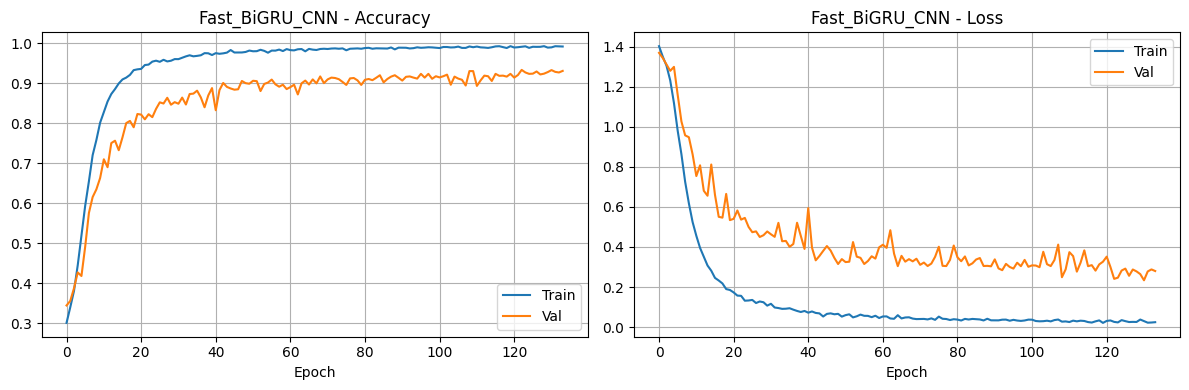

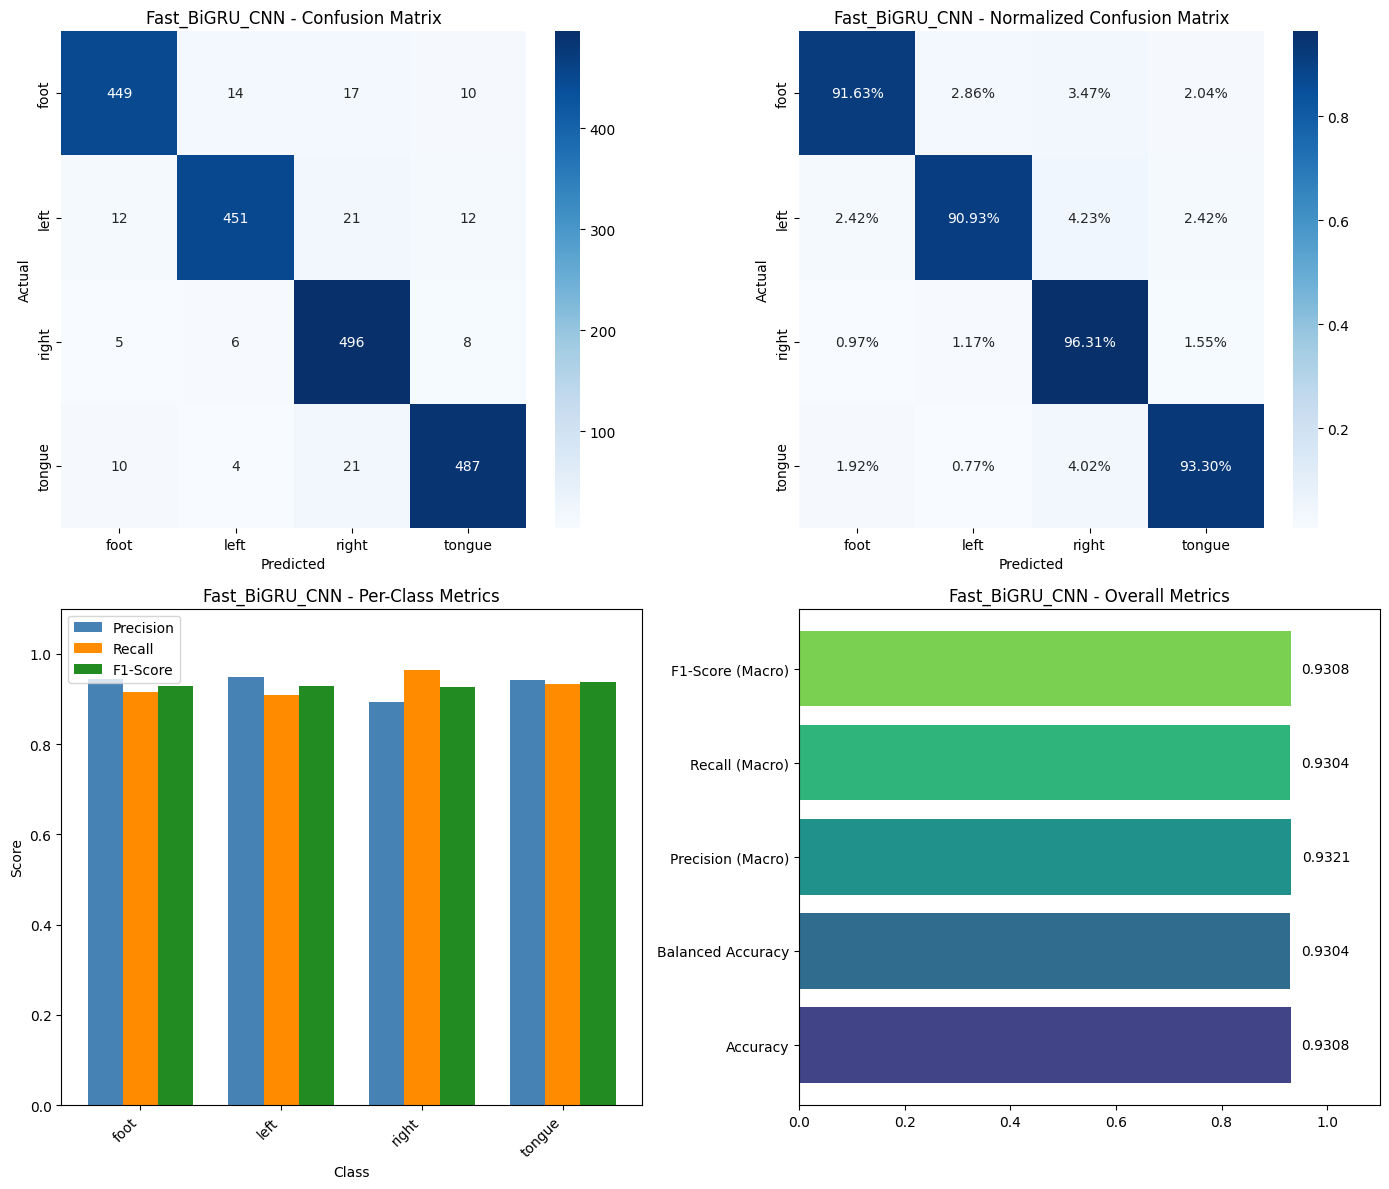


CLASSIFICATION REPORT - Fast_BiGRU_CNN
              precision    recall  f1-score   support

        foot       0.94      0.92      0.93       490
        left       0.95      0.91      0.93       496
       right       0.89      0.96      0.93       515
      tongue       0.94      0.93      0.94       522

    accuracy                           0.93      2023
   macro avg       0.93      0.93      0.93      2023
weighted avg       0.93      0.93      0.93      2023



In [35]:
CONFIGS = {'Fast_BiGRU_CNN': {
        'epochs': 134,
        'lr': 0.00023089698407387493,
        'optimizer': 'rmsprop',
        'batch_size': 16,
        'gru_units': 192,
        'conv_filters': 64,
        'conv_kernel': 5,
        'dense_units': 128,
        'spatial_dropout': 0.15,
        'dropout': 0.3
    }
}

cfg = CONFIGS['Fast_BiGRU_CNN']
train_loader, test_loader = create_dataloaders(X_train_seq, X_test_seq, y_train, y_test, cfg['batch_size'])
model = FastBiGRUCNN(
    input_size=X_train_seq.shape[2], num_classes=num_classes,
    gru_units=cfg['gru_units'], conv_filters=cfg['conv_filters'],
    conv_kernel=cfg['conv_kernel'], dense_units=cfg['dense_units'],
    spatial_dropout=cfg['spatial_dropout'], dropout=cfg['dropout']
)
model, hist, acc = train_model(model, train_loader, test_loader, epochs=cfg['epochs'],
                                lr=cfg['lr'],weight_decay = 2.4240971135904676e-05, optimizer_name=cfg['optimizer'], device=device, model_name='Fast_BiGRU_CNN')
plot_history(hist, 'Fast_BiGRU_CNN')
metrics, _ = plot_metrics(model, test_loader, 'Fast_BiGRU_CNN', label_encoder, device, num_classes)
results['Fast_BiGRU_CNN'] = acc
all_metrics['Fast_BiGRU_CNN'] = metrics
torch.save(model.state_dict(), 'fast_bigru_cnn_model.pt')